<h1> Import

In [1]:
import numpy as np

from masterthesis.data.loaders import load_cell_dataframe
from masterthesis.data.datasets import balanced_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot


<h1> Single Cell

<h2> Data

In [2]:
cell_df = load_cell_dataframe()
cell_df.head()


,CellID,CurrentData,VoltageData,TempData,StepIndex,CycleIndex,TimeData
0,GS3,0.0,4.197761,24.041702,9,1,0.0000
1,GS3,0.0,4.197635,23.955681,9,1,1.0003
2,GS3,0.0,4.197824,23.926302,9,1,2.0001
3,GS3,0.0,4.197635,23.979719,9,1,3.0004
4,GS3,0.0,4.197635,24.001940,9,1,4.0000


In [3]:
cols = ["CurrentData", "VoltageData", "TempData", "CycleIndex"]

groups = [
    [9, 11, 13, 15, 22],   # rest
    [10],                  # strong discharge
    [12],                  # medium discharge
    [14],                  # charge
    [17,18,19,20,21]       # dynamic experiments
]

env_df = balanced_env_dict(cell_df, cols, groups, sort_by="StepIndex")

<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=False,
    noise_std=0.000000000001,
    seed=42,
)


dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
after scale: [0.         0.14494844 0.38734498 1.43965203]
after noise: [1.00173586e-12 1.44948438e-01 3.87344976e-01 1.43965203e+00]


<h3> Dataset

In [5]:
interventions = {
    0: [],     # rest = observational
    1: [0],    # discharge
    2: [0],    # discharge
    3: [0],    # charge
    4: [0],    # dynamic excitation
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)

In [6]:
print(dataset.keys())
print(dataset['X'][0])
print(len(dataset['X']))

print(len(dataset['envs']))
print(dataset['envs'][0][9])

print(dataset['interventions'])
print(len(dataset['interventions']))

print(dataset["X"].shape)
print(dataset["X"][:5])
print(dataset["X"].std(axis=0))


dict_keys(['X', 'envs', 'interventions'])
[4.96714153e-13 4.19776106e+00 2.40417023e+01 1.00000000e+00]
172710
5
[2.08863595e-13 4.19769812e+00 2.39421234e+01 1.00000000e+00]
{0: [], 1: [0], 2: [0], 3: [0], 4: [0]}
5
(172710, 4)
[[ 4.96714153e-13  4.19776106e+00  2.40417023e+01  1.00000000e+00]
 [-2.34153375e-13  4.19763517e+00  2.39556808e+01  1.00000000e+00]
 [-4.69474386e-13  4.19782400e+00  2.39263020e+01  1.00000000e+00]
 [ 2.41962272e-13  4.19763517e+00  2.39797192e+01  1.00000000e+00]
 [-1.01283112e-12  4.19763517e+00  2.40019398e+01  1.00000000e+00]]
[3.05399581 0.27561743 0.87189851 2.5726625 ]


In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentData,VoltageData,TempData,CycleIndex
CurrentData,1.000000,0.375065,-0.277494,-0.065839
VoltageData,0.375065,1.000000,-0.085254,-0.935349
TempData,-0.277494,-0.085254,1.000000,-0.065392
CycleIndex,-0.065839,-0.935349,-0.065392,1.000000


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (34542, 4)
1 (34542, 4)
2 (34542, 4)
3 (34542, 4)
4 (34542, 4)


<h2> PC

In [9]:
dag_pc = run_pc(dataset_obs)
print(dag_pc)

  0%|          | 0/4 [00:00<?, ?it/s]

[[0 1 1 1]
 [1 0 1 1]
 [1 1 0 1]
 [1 1 1 0]]


<h2> No-Tears

In [10]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:02<00:00,  7.03it/s]

[[0 0 0 0]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 1 0]]


<h2> Third alg-Do Tears

In [11]:
dag_dotears = run_dotears(dataset, scaled=False)
print(dag_dotears)

0 h = 1.024839428170985
1 h = 0.23552023197419558
2 h = 0.05319913928119924
3 h = 0.011625125025360283
4 h = 0.0025303914282623907
5 h = 0.0005622819998141182
6 h = 0.00013200644808009088
7 h = 1.1508042612184965e-05
8 h = 2.460482230404182e-06
[[0 0 0 0]
 [0 0 1 1]
 [0 0 0 0]
 [0 0 0 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

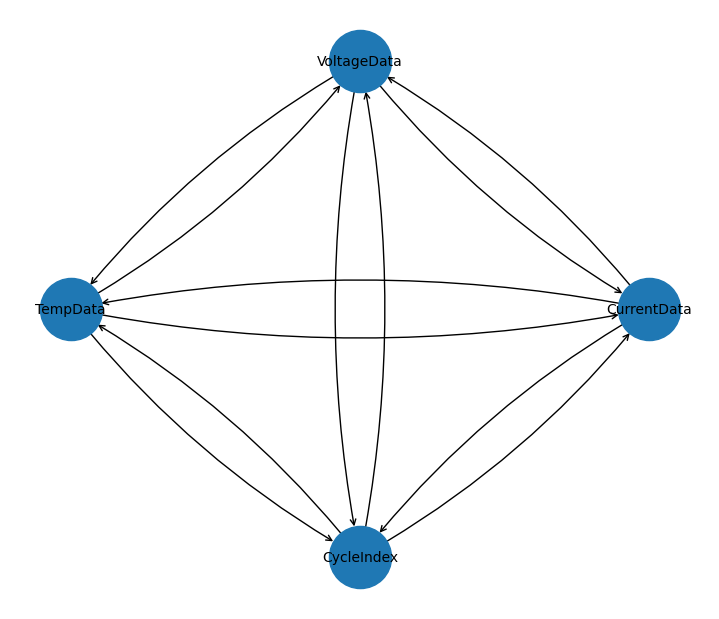

In [12]:
save_graph_plot(cols, dag_pc) 

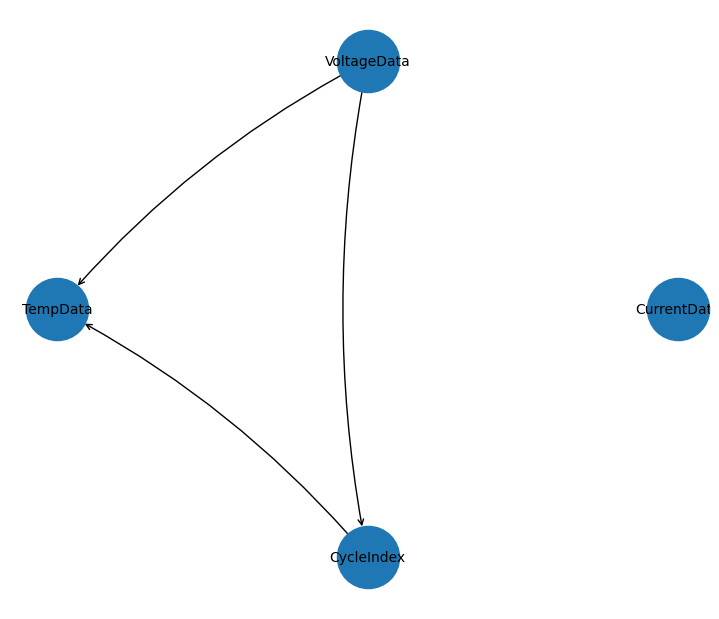

In [13]:
save_graph_plot(cols, dag_notears) 

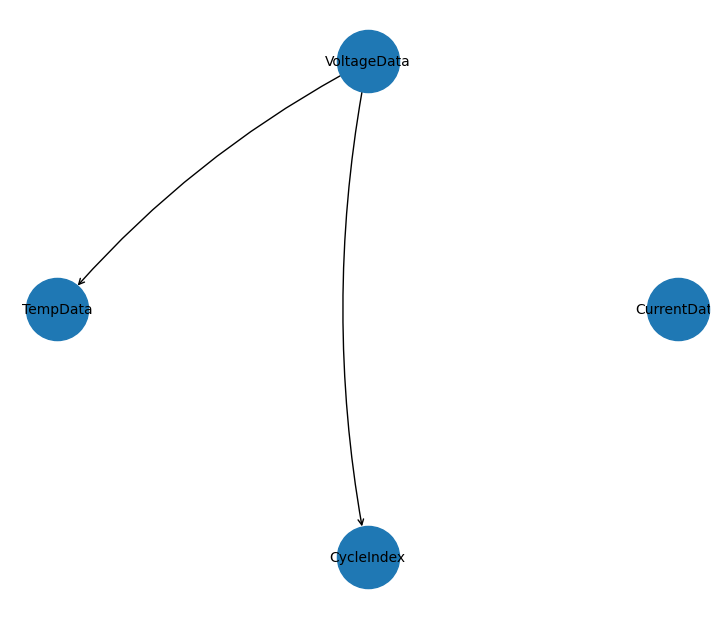

In [14]:
save_graph_plot(cols, dag_dotears) 